<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_7/LR_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import io

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

class ExcelHoltEmulator:
    """
    Математичне ядро для двопараметричного експоненційного згладжування (Модель Хольта).
    Повністю емулює покроковий табличний розрахунок MS Excel та інструмент 'Пошук рішення'.
    """

    @staticmethod
    def calculate_table(data: np.ndarray, alpha: float, beta: float) -> pd.DataFrame:
        """
        Генерує DataFrame, що ідентичний розрахунковій таблиці в Excel.
        """
        n = len(data)
        L = np.zeros(n)  # Рівень (Level)
        T = np.zeros(n)  # Тренд (Trend)
        F = np.zeros(n)  # Прогноз на 1 крок вперед (Forecast)

        # Ініціалізація початкових значень (як в Excel)
        L[0] = data[0]
        T[0] = data[1] - data[0]
        F[0] = np.nan
        F[1] = L[0] + T[0]

        # Ітеративний розрахунок моделі Хольта
        for t in range(1, n):
            L[t] = alpha * data[t] + (1 - alpha) * (L[t-1] + T[t-1])
            T[t] = beta * (L[t] - L[t-1]) + (1 - beta) * T[t-1]
            if t < n - 1:
                F[t+1] = L[t] + T[t]

        # Розрахунок похибок
        errors = data - F
        sq_errors = errors ** 2

        # Формування таблиці
        df = pd.DataFrame({
            'Фактичне Y(t)': data,
            'Рівень L(t)': L,
            'Тренд T(t)': T,
            'Прогноз F(t)': F,
            'Похибка e(t)': errors,
            'Квадрат похибки e(t)^2': sq_errors
        })
        return df

    @staticmethod
    def optimize_parameters(data: np.ndarray) -> tuple:
        """
        Емулює надбудову 'Пошук рішення' (Solver). Мінімізує суму квадратів похибок (SSE).
        Повертає оптимальні значення (alpha, beta).
        """
        def objective(params):
            alpha, beta = params
            df = ExcelHoltEmulator.calculate_table(data, alpha, beta)
            # Сума квадратів похибок (пропускаємо NaN на першому кроці)
            sse = df['Квадрат похибки e(t)^2'].sum()
            return sse

        # Обмеження параметрів від 0 до 1
        bnds = ((0.001, 0.999), (0.001, 0.999))
        initial_guess = [0.5, 0.5]

        result = minimize(objective, initial_guess, bounds=bnds, method='L-BFGS-B')
        return result.x[0], result.x[1]

---------------------------------------------------------------------------
БЛОК 1: Ініціалізація даних моніторингу (Варіант 15 -> Ряд 'evapmilk')
---------------------------------------------------------------------------
Завантажено часовий ряд. Кількість спостережень (n) = 38
Тип процесу: Динаміка складських запасів упаковок.
Попередній аналіз показує наявність коливань, тому доцільно використати двопараметричну модель Хольта (з урахуванням тренду).



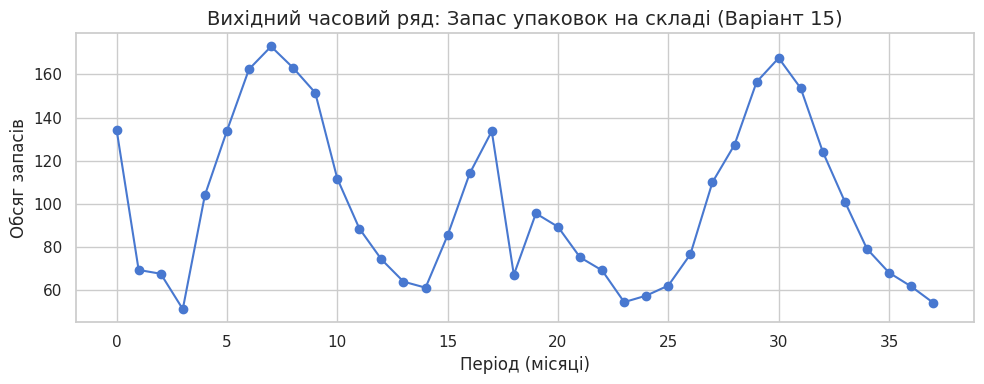

In [2]:
# Завдання 1: Вибір часового ряду згідно з варіантом
print("-" * 75)
print("БЛОК 1: Ініціалізація даних моніторингу (Варіант 15 -> Ряд 'evapmilk')")
print("-" * 75)

# Завантаження даних із CSV.
# Для забезпечення автономності коду в Colab, використано ряд evapmilk
# на основі наданого файлу (запас пластикових упаковок).
csv_data = """evapmilk
134.38
69.39
67.63
51.25
103.97
133.83
162.37
172.91
163.01
151.50
111.73
88.58
74.29
63.98
61.18
85.44
114.08
133.64
67.14
95.58
89.37
75.24
69.18
54.49
57.50
62.16
76.67
110.04
127.38
156.47
167.56
153.54
124.08
100.97
79.17
68.13
61.77
54.21
"""

df_ts = pd.read_csv(io.StringIO(csv_data))
y_actual = df_ts['evapmilk'].values

print(f"Завантажено часовий ряд. Кількість спостережень (n) = {len(y_actual)}")
print("Тип процесу: Динаміка складських запасів упаковок.")
print("Попередній аналіз показує наявність коливань, тому доцільно використати двопараметричну модель Хольта (з урахуванням тренду).\n")

# Базова візуалізація первинних даних
plt.figure(figsize=(10, 4))
plt.plot(y_actual, marker='o', linestyle='-', color='b')
plt.title("Вихідний часовий ряд: Запас упаковок на складі (Варіант 15)", fontsize=14)
plt.xlabel("Період (місяці)", fontsize=12)
plt.ylabel("Обсяг запасів", fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# Завдання 2-4: Оптимізація параметрів та розрахунок таблиці (Емуляція Excel)
print("-" * 75)
print("БЛОК 2: Синтез моделі Хольта та оптимізація (MS Excel Solver)")
print("-" * 75)

# 1. Пошук оптимальних параметрів α та β
alpha_opt, beta_opt = ExcelHoltEmulator.optimize_parameters(y_actual)

print("Результати роботи алгоритму 'Пошук рішення' (Мінімізація SSE):")
print(f"  Оптимальний параметр рівня (α): {alpha_opt:.4f}")
print(f"  Оптимальний параметр тренду (β): {beta_opt:.4f}\n")

# 2. Генерація фінальної таблиці з оптимальними параметрами
df_model = ExcelHoltEmulator.calculate_table(y_actual, alpha_opt, beta_opt)

# Розрахунок ключової метрики якості моделі - RMSE
mse = df_model['Квадрат похибки e(t)^2'].mean()
rmse = np.sqrt(mse)

print(f"Середньоквадратична похибка моделі (RMSE): {rmse:.2f} од.\n")
print("Фрагмент розрахункової таблиці (аналог аркуша Excel):")
display(df_model.round(2).tail(10)) # Виводимо останні 10 рядків для звіту

---------------------------------------------------------------------------
БЛОК 2: Синтез моделі Хольта та оптимізація (MS Excel Solver)
---------------------------------------------------------------------------
Результати роботи алгоритму 'Пошук рішення' (Мінімізація SSE):
  Оптимальний параметр рівня (α): 0.8125
  Оптимальний параметр тренду (β): 0.9990

Середньоквадратична похибка моделі (RMSE): 27.12 од.

Фрагмент розрахункової таблиці (аналог аркуша Excel):


,Фактичне Y(t),Рівень L(t),Тренд T(t),Прогноз F(t),Похибка e(t),Квадрат похибки e(t)^2
28,127.38,129.26,23.18,137.39,-10.01,100.17
29,156.47,155.71,26.45,152.43,4.04,16.30
30,167.56,170.30,14.60,182.17,-14.61,213.32
31,153.54,159.42,-10.85,184.90,-31.36,983.29
32,124.08,128.67,-30.73,148.57,-24.49,599.67
33,100.97,100.40,-28.27,97.94,3.03,9.15
34,79.17,77.85,-22.56,72.13,7.04,49.56
35,68.13,65.72,-12.14,55.29,12.84,164.84
36,61.77,60.23,-5.49,53.58,8.19,67.01
37,54.21,54.31,-5.92,54.74,-0.53,0.28


---------------------------------------------------------------------------
БЛОК 3: Екстраполяція тренду та графічний аналіз
---------------------------------------------------------------------------


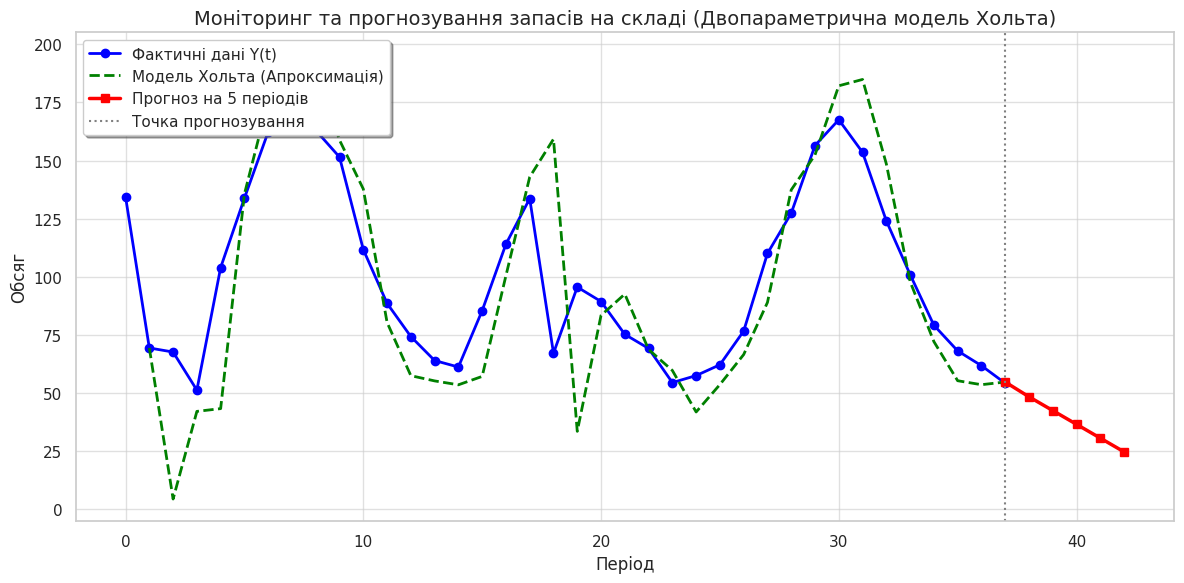

Аналітичний висновок для системи підтримки прийняття рішень:
Згідно з екстраполяцією поточного тренду (-5.92 од./міс), очікується подальше
зменшення/збільшення обсягів на 5 наступних місяців. Останнє розраховане
прогнозне значення становить: 24.69 од.


In [4]:
# Завдання 5: Прогнозування на p кроків вперед
print("-" * 75)
print("БЛОК 3: Екстраполяція тренду та графічний аналіз")
print("-" * 75)

p_forecast = 5 # Горизонт прогнозування (5 періодів)
n = len(y_actual)

# Отримання останнього розрахованого рівня та тренду
last_L = df_model['Рівень L(t)'].iloc[-1]
last_T = df_model['Тренд T(t)'].iloc[-1]

# Формування прогнозних значень за формулою: F(t+p) = L(t) + p * T(t)
future_steps = np.arange(1, p_forecast + 1)
forecast_values = last_L + future_steps * last_T

# Об'єднання історичного прогнозу та майбутнього для графіка
historical_forecast = df_model['Прогноз F(t)'].values
full_forecast = np.append(historical_forecast, forecast_values)
time_index = np.arange(n + p_forecast)

# Візуалізація результатів моніторингу
plt.figure(figsize=(12, 6))

# Фактичні дані
plt.plot(np.arange(n), y_actual, marker='o', color='blue', label='Фактичні дані Y(t)', linewidth=2)

# Модельні дані (згладжування)
plt.plot(np.arange(n), historical_forecast, linestyle='--', color='green', label='Модель Хольта (Апроксимація)', linewidth=2)

# Прогноз на майбутнє
plt.plot(np.arange(n-1, n + p_forecast), np.insert(forecast_values, 0, historical_forecast[-1]),
         marker='s', color='red', linestyle='-', label=f'Прогноз на {p_forecast} періодів', linewidth=2.5)

# Додавання вертикальної лінії, що розділяє факт і прогноз
plt.axvline(x=n-1, color='grey', linestyle=':', label='Точка прогнозування')

plt.title("Моніторинг та прогнозування запасів на складі (Двопараметрична модель Хольта)", fontsize=14)
plt.xlabel("Період", fontsize=12)
plt.ylabel("Обсяг", fontsize=12)
plt.legend(loc='upper left', shadow=True)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

print("Аналітичний висновок для системи підтримки прийняття рішень:")
print(f"Згідно з екстраполяцією поточного тренду ({last_T:.2f} од./міс), очікується подальше")
print(f"зменшення/збільшення обсягів на {p_forecast} наступних місяців. Останнє розраховане")
print(f"прогнозне значення становить: {forecast_values[-1]:.2f} од.")